# TimeSeriesHandler Auto-Processing Demo

This notebook builds a small multivariate sample time series with trend, seasonality, missing values, and outliers, then runs `TimeSeriesHandler` with `self_tune=True` so we can inspect the chosen preprocessing strategy.

In [1]:
import os
import sys

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from foreblocks.ts_handler import TimeSeriesHandler

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

In [2]:
rng = np.random.default_rng(7)

n = 24 * 21
timestamps = pd.date_range("2025-01-01", periods=n, freq="H")
t = np.arange(n, dtype=float)

daily = np.sin(2 * np.pi * t / 24.0)
weekly = np.sin(2 * np.pi * t / (24.0 * 7.0))
trend = 0.003 * t

feature_1 = 2.0 + trend + 0.9 * daily + 0.35 * weekly + 0.25 * rng.normal(size=n)
feature_2 = 1.0 + 0.6 * np.cos(2 * np.pi * t / 24.0 + 0.7) + 0.2 * weekly + 0.22 * rng.normal(size=n)
feature_3 = 0.5 + 0.35 * trend + 0.5 * daily - 0.25 * weekly + 0.18 * rng.normal(size=n)

data = np.column_stack([feature_1, feature_2, feature_3]).astype(float)

missing_idx = rng.choice(n, size=28, replace=False)
data[missing_idx[:10], 0] = np.nan
data[missing_idx[10:18], 1] = np.nan
data[missing_idx[18:], 2] = np.nan

spike_idx = rng.choice(np.arange(24, n - 24), size=10, replace=False)
data[spike_idx[:4], 0] += rng.normal(3.5, 0.5, size=4)
data[spike_idx[4:7], 1] -= rng.normal(2.8, 0.4, size=3)
data[spike_idx[7:], 2] += rng.normal(2.2, 0.3, size=3)

columns = ["load", "temperature_proxy", "reservoir_proxy"]
raw_df = pd.DataFrame(data, index=timestamps, columns=columns)
raw_df.head()

,load,temperature_proxy,reservoir_proxy
2025-01-01 00:00:00,2.000308,1.639433,0.431206
2025-01-01 01:00:00,2.323710,1.262338,0.699610
2025-01-01 02:00:00,2.413621,1.027666,0.744429
2025-01-01 03:00:00,2.461936,0.656932,0.837615
2025-01-01 04:00:00,2.729920,0.837911,0.848435


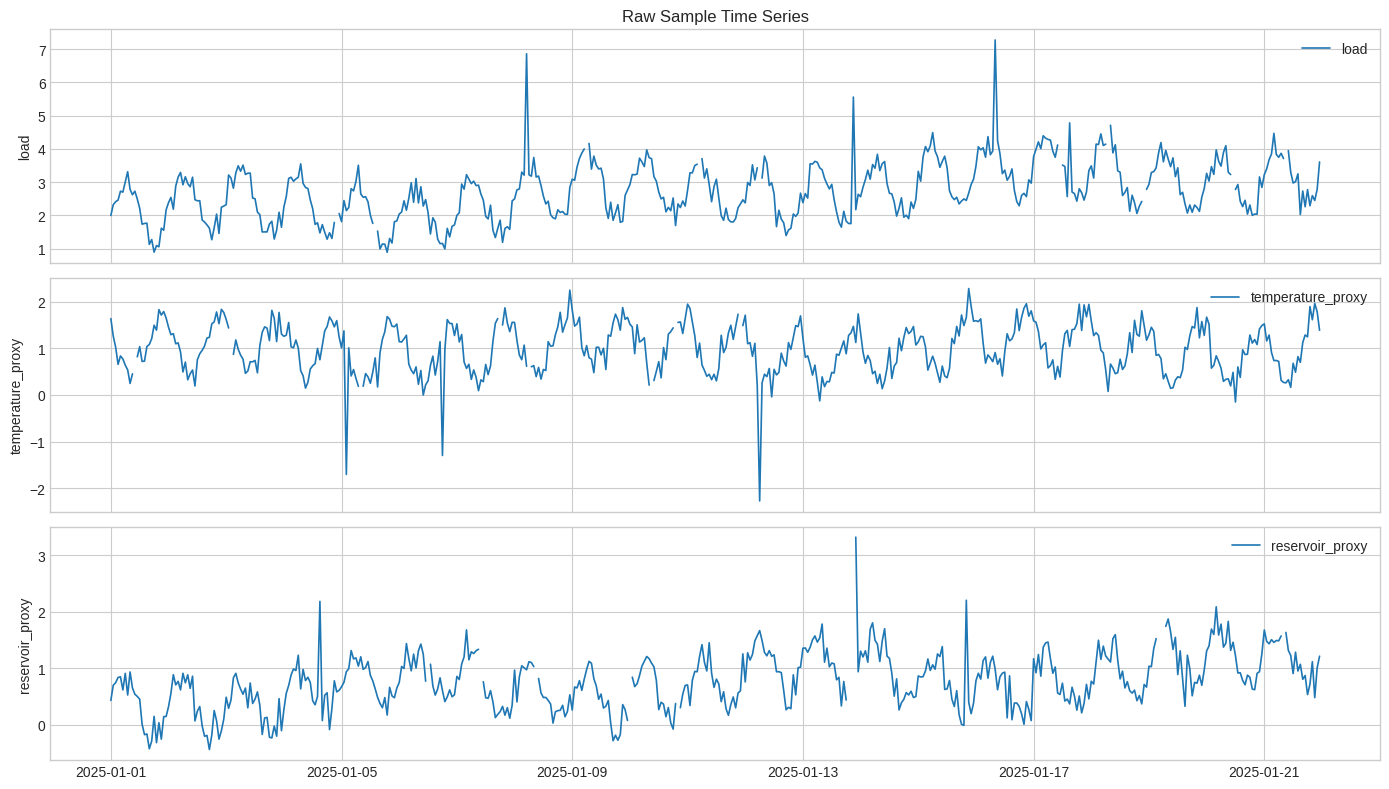

Shape: (504, 3)
Missing fraction: {'load': 0.0198, 'temperature_proxy': 0.0159, 'reservoir_proxy': 0.0198}


In [3]:
fig, axes = plt.subplots(len(columns), 1, figsize=(14, 8), sharex=True)
for i, col in enumerate(columns):
    axes[i].plot(raw_df.index, raw_df[col], label=col, linewidth=1.2)
    axes[i].set_ylabel(col)
    axes[i].legend(loc="upper right")
axes[0].set_title("Raw Sample Time Series")
plt.tight_layout()
plt.show()

print("Shape:", raw_df.shape)
print("Missing fraction:", raw_df.isna().mean().round(4).to_dict())

In [4]:
handler = TimeSeriesHandler(
    window_size=48,
    horizon=12,
    self_tune=True,
    generate_time_features=True,
    verbose=False,
)

X, y, processed, time_features = handler.fit_transform(
    raw_df.values,
    time_stamps=raw_df.index.to_numpy(),
)

processed_df = pd.DataFrame(processed, index=raw_df.index, columns=columns)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("time feature shape:", None if time_features is None else time_features.shape)


[Auto-Configuration — robust evidence-based edition]
[Auto-Filter Ranking]
        score  fidelity_mse  roughness  residual_autocorr  derivative_corr
method                                                                    
none     0.15        0.0000     0.4372             0.0000           1.0000
kalman   0.21        0.0000     0.4372             0.0000           1.0000
savgol   0.47        0.0459     0.2312             0.1152           0.4289

+--------------------+----------------+
|     Parameter      | Configuration  |
+--------------------+----------------+
| Dataset Dimensions |    504 × 3     |
|   Missing Values   |     1.85%      |
|    Stationarity    | Non-stationary |
|    Seasonality     |    Present     |
|   Transformation   |      None      |
|      Scaling       |     robust     |
| Signal Processing  |      None      |
|     Imputation     |   iterative    |
| Outlier Detection  |      mad       |
| Outlier Threshold  |      4.60      |
|   Decomposition    |    5 

In [5]:
summary = {
    "filter_method": handler.filter_method,
    "apply_filter": handler.apply_filter,
    "impute_method": handler.impute_method,
    "apply_imputation": handler.apply_imputation,
    "outlier_method": handler.outlier_method,
    "remove_outliers": handler.remove_outliers,
    "scaling_method": handler.scaling_method,
    "log_transform": handler.log_transform,
    "detrend": handler.detrend,
    "seasonal": handler.seasonal,
    "ewt_bands": handler.ewt_bands,
}

pd.Series(summary)

filter_method            none
apply_filter            False
impute_method       iterative
apply_imputation         True
outlier_method            mad
remove_outliers          True
scaling_method         robust
log_transform           False
detrend                  True
seasonal                 True
ewt_bands                   5
dtype: object

In [6]:
scores = handler.filter_selection_.get("scores")
if isinstance(scores, pd.DataFrame) and not scores.empty:
    display(scores.round(4))
else:
    print("No auto-filter ranking table was generated.")

,fidelity_mse,roughness,residual_autocorr,derivative_corr,score
method,,,,,
none,0.0000,0.4372,0.0000,1.0000,0.15
kalman,0.0000,0.4372,0.0000,1.0000,0.21
savgol,0.0459,0.2312,0.1152,0.4289,0.47
stl,0.0949,0.1599,0.0523,0.3488,0.53
ssa,0.1477,0.0607,0.2050,0.2790,0.74
lowess,0.1553,0.0560,0.2339,0.2560,0.90


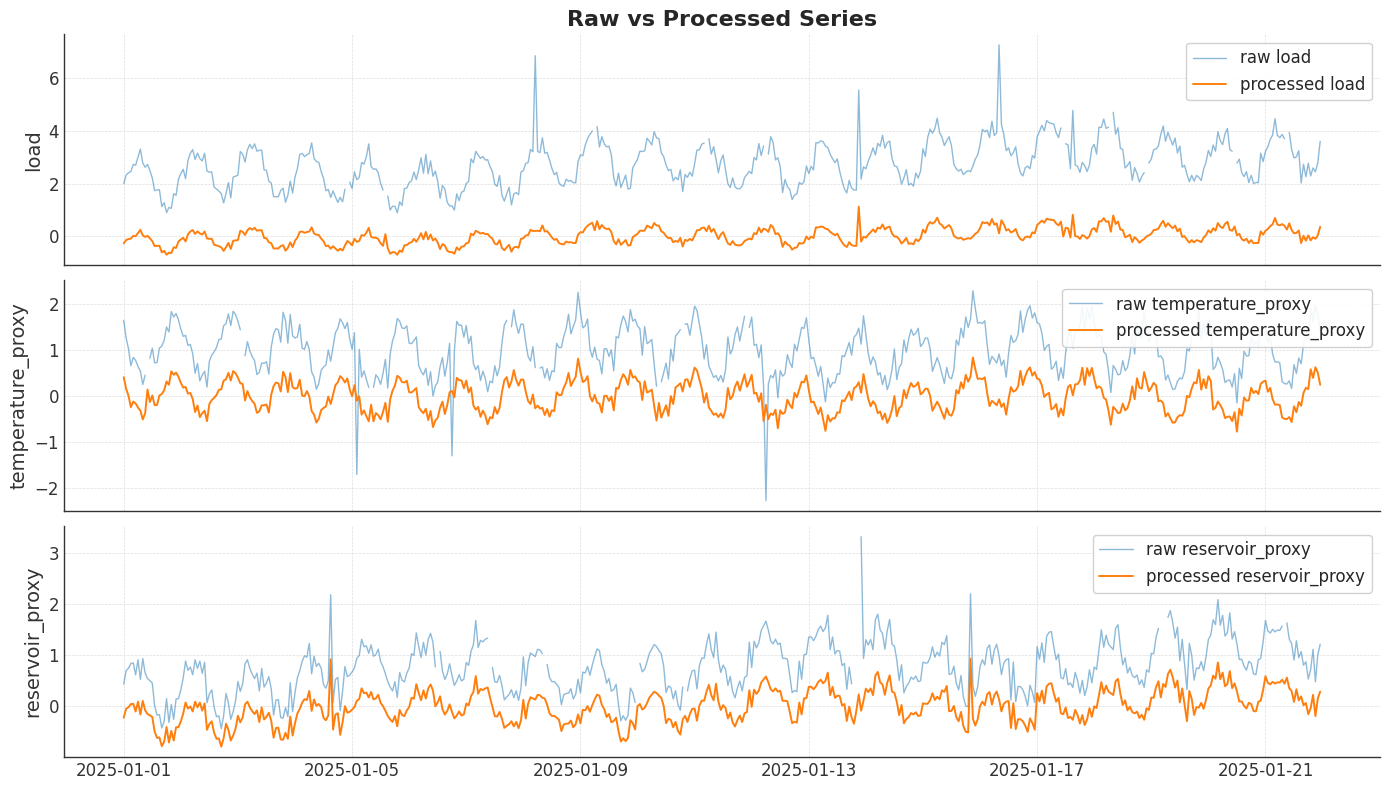

In [7]:
fig, axes = plt.subplots(len(columns), 1, figsize=(14, 8), sharex=True)
for i, col in enumerate(columns):
    axes[i].plot(raw_df.index, raw_df[col], label=f"raw {col}", alpha=0.5, linewidth=1.0)
    axes[i].plot(processed_df.index, processed_df[col], label=f"processed {col}", linewidth=1.4)
    axes[i].set_ylabel(col)
    axes[i].legend(loc="upper right")
axes[0].set_title("Raw vs Processed Series")
plt.tight_layout()
plt.show()

In [8]:
sample_idx = 0
print("First input window shape:", X[sample_idx].shape)
print("First target window shape:", y[sample_idx].shape)
print("First input window (first 5 rows):")
print(pd.DataFrame(X[sample_idx][:5], columns=columns))

print("\nFirst target window:")
print(pd.DataFrame(y[sample_idx], columns=columns))

First input window shape: (48, 3)
First target window shape: (12, 3)
First input window (first 5 rows):
       load  temperature_proxy  reservoir_proxy
0 -0.271666           0.408130        -0.223269
1 -0.145157           0.159055        -0.048168
2 -0.109986           0.004052        -0.018929
3 -0.091086          -0.240822         0.041864
4  0.013744          -0.121284         0.048923

First target window:
        load  temperature_proxy  reservoir_proxy
0  -0.144709           0.397109        -0.186568
1   0.204717           0.276262        -0.314404
2   0.168298           0.261588        -0.217946
3   0.048956          -0.097618         0.037149
4   0.228869           0.106111         0.089433
5   0.312365          -0.025983        -0.020392
6   0.248540          -0.109332        -0.093410
7   0.320657          -0.166788        -0.151818
8   0.210892          -0.367460        -0.080866
9   0.225233          -0.334933        -0.308717
10  0.226114          -0.202658        -0.02227

## Next ideas

- Swap the synthetic `raw_df` for a real project series.
- Try `plot=True` on the handler if you want internal preprocessing comparison plots.
- Compare `self_tune=True` against a fixed manual configuration on the same data.

In [ ]:
from __future__ import annotations

import numpy as np
import pandas as pd

from foretools import AdaptiveMI, AdaptiveMRMR
from foretools.fengineer import FeatureConfig
from foretools.fengineer.selectors.feature_selector import FeatureSelector


class ToyAdaptiveMI:
    """
    Tiny deterministic scorer used only to illustrate why MID and MIQ can
    select different features from the same relevance/redundancy structure.
    """

    def __init__(self, feature_names):
        self.feature_names = list(feature_names)
        self._relevance = {
            "lead": 0.95,
            "candidate_mid": 0.92,
            "candidate_miq": 0.75,
        }
        self._redundancy = {
            frozenset(("lead", "candidate_mid")): 0.30,
            frozenset(("lead", "candidate_miq")): 0.12,
            frozenset(("candidate_mid", "candidate_miq")): 0.18,
        }
        self._values_to_name = {}

    def bind_columns(self, X_values):
        self._values_to_name = {
            tuple(np.asarray(X_values[:, idx], dtype=float).tolist()): name
            for idx, name in enumerate(self.feature_names)
        }

    def score_pairwise(self, X_values, y_values, return_raw_mi=False):
        self.bind_columns(X_values)
        return np.array([self._relevance[name] for name in self.feature_names], dtype=float)

    def score(self, xa, xb, return_raw_mi=False):
        a = self._values_to_name[tuple(np.asarray(xa, dtype=float).tolist())]
        b = self._values_to_name[tuple(np.asarray(xb, dtype=float).tolist())]
        return float(self._redundancy[frozenset((a, b))])


def _print_title(title: str) -> None:
    print()
    print(title)
    print("-" * len(title))


def demo_criterion_difference() -> None:
    _print_title("Toy scorer: MID and MIQ can diverge")

    X = pd.DataFrame(
        {
            "lead": [0.0, 1.0, 2.0, 3.0],
            "candidate_mid": [10.0, 11.0, 12.0, 13.0],
            "candidate_miq": [20.0, 21.0, 22.0, 23.0],
        }
    )
    y = pd.Series([0.0, 1.0, 0.0, 1.0])

    for criterion in ("mid", "miq"):
        selector = AdaptiveMRMR(
            scorer=ToyAdaptiveMI(X.columns),
            criterion=criterion,
            candidate_pool=3,
            stable_relevance=False,
            random_state=7,
        )
        selector.fit(
            X,
            y,
            min_features=2,
            max_features=2,
            mi_threshold=0.0,
            min_samples=1,
        )
        print(f"{criterion.upper()} selected: {selector.selected_features_}")
        print(selector.selection_scores_)


def demo_real_usage() -> None:
    _print_title("Real AdaptiveMRMR usage on synthetic data")

    rng = np.random.default_rng(42)
    n = 320

    lead = rng.normal(size=n)
    duplicate = lead + 0.03 * rng.normal(size=n)
    complementary = rng.normal(size=n)
    weak = rng.normal(size=n)
    y = pd.Series(1.3 * lead + 0.75 * complementary + 0.05 * rng.normal(size=n))
    X = pd.DataFrame(
        {
            "lead": lead,
            "duplicate": duplicate,
            "complementary": complementary,
            "weak": weak,
        }
    )

    for criterion in ("mid", "miq"):
        selector = AdaptiveMRMR(
            scorer=AdaptiveMI(random_state=42, rho_threshold=0.3),
            criterion=criterion,
            candidate_pool=4,
            stable_relevance=False,
            random_state=42,
        )
        selector.fit(
            X,
            y,
            min_features=2,
            max_features=2,
            mi_threshold=0.0,
        )
        print(f"{criterion.upper()} selected: {selector.selected_features_}")
        print("note: on this synthetic dataset both criteria agree on the kept features")
        print("relevance:")
        print(selector.relevance_scores_)
        print("selection scores:")
        print(selector.selection_scores_)

    cfg = FeatureConfig(
        selector_method="mrmr",
        selector_stable_mi=False,
        min_features=2,
        max_features=2,
        mi_threshold=0.0,
        mrmr_candidate_pool=4,
        mrmr_criterion="miq",
    )
    fs = FeatureSelector(cfg)
    fs.ami_scorer = AdaptiveMI(random_state=42, rho_threshold=0.3)
    fs.fit(X, y)
    print("FeatureSelector with mRMR/MIQ selected:", fs.selected_features_)


if __name__ == "__main__":
    demo_criterion_difference()
    demo_real_usage()



Toy scorer: MID and MIQ can diverge
-----------------------------------
MID selected: ['lead', 'candidate_miq']
lead             0.95
candidate_miq    0.63
dtype: float64
MIQ selected: ['lead', 'candidate_miq']
candidate_miq    6.249999
lead             0.950000
dtype: float64

Real AdaptiveMRMR usage on synthetic data
-----------------------------------------
MID selected: ['lead', 'complementary']
note: on this synthetic dataset both criteria agree on the kept features
relevance:
lead             0.819979
duplicate        0.818125
complementary    0.453093
weak             0.000000
dtype: float64
selection scores:
lead             0.819979
complementary    0.453093
dtype: float64
MIQ selected: ['lead', 'complementary']
note: on this synthetic dataset both criteria agree on the kept features
relevance:
lead             0.819979
duplicate        0.818125
complementary    0.453093
weak             0.000000
dtype: float64
selection scores:
complementary    4.530931e+07
lead             

: 